In [1]:
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont

class TypographyFeatureExtractor:
    """
    Клас для автоматичного аналізу та вилучення топологічних та текстурних 
    характеристик із сегментованого корейського тексту манхви.
    """
    def __init__(self, korean_mask_path: str, korean_img_path: str):
        # Завантаження маски у градаціях сірого та оригінального кольорового зображення
        self.mask = cv2.imread(korean_mask_path, cv2.IMREAD_GRAYSCALE)
        self.image = cv2.imread(korean_img_path, cv2.IMREAD_COLOR)
        
        if self.mask is None or self.image is None:
            raise ValueError("Критична помилка: Неможливо завантажити вхідні зображення.")
            
        # Бінаризація маски для забезпечення чіткості меж аналізу
        _, self.binary_mask = cv2.threshold(self.mask, 127, 255, cv2.THRESH_BINARY)

    def extract_geometric_ratio(self) -> dict:
        """Обчислення 4 екстремальних точок для ВСЬОГО тексту (з уникненням перекосу)."""
        contours, _ = cv2.findContours(self.binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Фільтруємо дрібний шум (щоб випадкова крапка на фоні не зламала геометрію)
        valid_contours = [c for c in contours if cv2.contourArea(c) > 50]
        
        if not valid_contours:
            # Дефолтний квадрат, якщо маска порожня
            default_corners = np.array([[0,0], [512,0], [512,512], [0,512]], dtype="float32")
            return {"corners": default_corners}
            
        # 1. ОБ'ЄДНУЄМО ВСІ СИМВОЛИ в один масив точок, щоб охопити весь напис
        all_pts = np.vstack(valid_contours).reshape(-1, 2)
        
        # 2. Знаходимо МІНІМАЛЬНИЙ ПРЯМОКУТНИК, що описує весь цей напис 
        # (Ця функція розуміє нахил і гарантує, що кути будуть прямими, під 90 градусів)
        rect = cv2.minAreaRect(all_pts)
        box = cv2.boxPoints(rect) # Отримуємо 4 ідеальні кути цього прямокутника
        
        # 3. Сортуємо 4 кути (Верх-Ліво, Верх-Право, Низ-Право, Низ-Ліво)
        corners = np.zeros((4, 2), dtype="float32")
        
        s = box.sum(axis=1)
        corners[0] = box[np.argmin(s)]  # Top-Left
        corners[2] = box[np.argmax(s)]  # Bottom-Right
        
        diff = np.diff(box, axis=1)
        corners[1] = box[np.argmin(diff)]  # Top-Right
        corners[3] = box[np.argmax(diff)]  # Bottom-Left
        
        return {"corners": corners}

    def analyze_edge_morphology(self) -> str:
        """Визначення топології країв (гострі або заокруглені) на основі циркулярності."""
        contours, _ = cv2.findContours(self.binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return "neutral"
            
        # Вибір найбільшого контуру, який ймовірно є основним текстовим блоком
        main_contour = max(contours, key=cv2.contourArea)
        perimeter = cv2.arcLength(main_contour, True)
        area = cv2.contourArea(main_contour)
        
        # Математичне обчислення циркулярності (Circularity)
        circularity = 4 * np.pi * (area / (perimeter * perimeter + 1e-6))
        
        # Евристичні пороги, адаптовані для манхва-типографіки
        if circularity > 0.18:
            return "rounded"
        else:
            return "sharp"

    def detect_texture_and_gradients(self) -> dict:
        """Виявлення наявності градієнтів та складних текстур (ОНОВЛЕНО ДЛЯ КОЛЬОРУ)."""
        # Накладання маски на зображення для ізоляції тексту від фону
        masked_img = cv2.bitwise_and(self.image, self.image, mask=self.binary_mask)
        
        # 1. ПЕРЕВЕДЕННЯ В HSV ДЛЯ АНАЛІЗУ КОЛЬОРУ
        hsv_masked = cv2.cvtColor(masked_img, cv2.COLOR_BGR2HSV)
        h_channel, s_channel, v_channel = cv2.split(hsv_masked)
        
        # Обчислення дисперсії для Відтінку (Hue) та Яскравості (Value)
        _, stddev_h = cv2.meanStdDev(h_channel, mask=self.binary_mask)
        _, stddev_v = cv2.meanStdDev(v_channel, mask=self.binary_mask)
        
        # Беремо найбільше відхилення: текст може змінювати або колір, або яскравість
        color_variance = max(float(stddev_h[0][0]), float(stddev_v[0][0]))
        
        # 2. АНАЛІЗ ТЕКСТУРИ (Залишаємо в сірому для виявлення зернистості)
        gray_masked = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
        laplacian_variance = cv2.Laplacian(gray_masked, cv2.CV_64F).var()
        
        # 3. ЗНИЖЕНІ ПОРОГИ ЧУТЛИВОСТІ
        has_gradient = color_variance > 8.0 # Було 15.0, тепер ловить м'якші градієнти
        has_texture = laplacian_variance > 300.0 # Було 500.0
        
        return {
            "has_gradient": has_gradient, 
            "has_texture": has_texture,
            "color_variance": color_variance,
            "texture_complexity": laplacian_variance
        }

In [2]:
def render_and_warp_cyrillic_text(geometry_params: dict, canvas_size: tuple = (512, 512)) -> np.ndarray:
    """
    Рендеринг слова 'Тест' та його анізотропна деформація (розтягування/стиснення) 
    для відтворення просторових пропорцій корейського оригіналу.
    """
    # Створення чорного базового полотна
    base_image = Image.new("L", canvas_size, color=0)
    draw_context = ImageDraw.Draw(base_image)
    
    # Використання максимально масивного шрифту як базової структури для коміксів
    try:
        font = ImageFont.truetype("arialbd.ttf", 150)
    except IOError:
        font = ImageFont.load_default()
        
    target_text = "Тест"
    
    # Визначення фізичних розмірів відрендереного тексту
    bounding_box = draw_context.textbbox((0, 0), target_text, font=font)
    text_width = bounding_box - bounding_box
    text_height = bounding_box - bounding_box
    
    # Центрування тексту на полотні
    center_x = (canvas_size - text_width) // 2
    center_y = (canvas_size - text_height) // 2
    draw_context.text((center_x, center_y), target_text, fill=255, font=font)
    
    rendered_array = np.array(base_image)
    
    # Отримання цільового та поточного співвідношення сторін
    target_aspect_ratio = geometry_params["aspect_ratio"]
    current_aspect_ratio = text_width / float(text_height)
    
    # Обчислення нових розмірів для анізотропної деформації
    if current_aspect_ratio > target_aspect_ratio:
        # Українське слово занадто широке -> горизонтальне стиснення
        warped_width = int(text_width * (target_aspect_ratio / current_aspect_ratio))
        warped_height = text_height
    else:
        # Українське слово занадто вузьке -> горизонтальне розтягування
        warped_width = text_width
        warped_height = int(text_height * (current_aspect_ratio / target_aspect_ratio))
        
    # Кадрування тексту для усунення зайвого фону перед деформацією
    rx, ry, rw, rh = cv2.boundingRect(rendered_array)
    cropped_cyrillic = rendered_array[ry:ry+rh, rx:rx+rw]
    
    # Афінне масштабування з кубічною інтерполяцією для запобігання втраті піксельної щільності
    warped_text = cv2.resize(cropped_cyrillic, (warped_width, warped_height), interpolation=cv2.INTER_CUBIC)
    
    # Формування нового полотна з деформованим текстом
    final_canvas = np.zeros(canvas_size, dtype=np.uint8)
    start_x = (canvas_size - warped_width) // 2
    start_y = (canvas_size - warped_height) // 2
    
    final_canvas[start_y:start_y+warped_height, start_x:start_x+warped_width] = warped_text
    
    # Жорстка бінаризація після інтерполяції для отримання ідеально гострих країв
    _, binary_warped_mask = cv2.threshold(final_canvas, 127, 255, cv2.THRESH_BINARY)
    
    return binary_warped_mask

In [3]:
def apply_morphological_edge_adaptation(warped_mask: np.ndarray, edge_style: str) -> np.ndarray:
    """
    Модифікація мікроструктури країв маски тексту для досягнення
    ефекту заокруглення або агресивного загострення за допомогою OpenCV.
    """
    adapted_mask = warped_mask.copy()
    
    if edge_style == "rounded":
        # Застосування інтенсивного розмиття Гауса для пом'якшення всіх кутів.
        # Розмір ядра (25, 25) гарантує значне перекриття просторових частот.
        blurred_mask = cv2.GaussianBlur(adapted_mask, (25, 25), 0)
        
        # Застосування жорсткого порогу відновлює різкість межі, 
        # конвертуючи розмиті кути у математично правильні дуги.
        _, adapted_mask = cv2.threshold(blurred_mask, 127, 255, cv2.THRESH_BINARY)
        
    elif edge_style == "sharp":
        # Створення морфологічних структурних елементів з гострими контурами
        rect_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        cross_kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (9, 9))
        
        # Хрестоподібна дилатація виштовхує пікселі назовні по діагоналях та осях,
        # створюючи візуальні "шипи" на кутах літер.
        dilated_mask = cv2.dilate(adapted_mask, cross_kernel, iterations=2)
        
        # Ерозія прямокутним ядром частково повертає товщину літер до норми, 
        # залишаючи при цьому згенеровані гострі виступи на краях.
        adapted_mask = cv2.erode(dilated_mask, rect_kernel, iterations=1)
        
    return adapted_mask

In [4]:
import torch
import cv2
import numpy as np
from PIL import Image
from diffusers import StableDiffusionXLControlNetPipeline, ControlNetModel
from diffusers import EulerAncestralDiscreteScheduler

def generate_texture_zero_shot(
    ukr_adapted_mask: np.ndarray, 
    korean_style_image_path: str, 
    texture_params: dict
) -> np.ndarray:
    
    # 1. Підготовка просторових умов (Canny Edge Map)
    mask_uint8 = ukr_adapted_mask.astype(np.uint8)
    edges_map = cv2.Canny(mask_uint8, 100, 200)
    edges_3c = cv2.cvtColor(edges_map, cv2.COLOR_GRAY2RGB)
    controlnet_cond_image = Image.fromarray(edges_3c)
    
    # IP-Adapter "сліпне" від великого чорного фону, тому ми вирізаємо лише сам текст
    style_cv = cv2.imread(korean_style_image_path)
    style_cv = cv2.cvtColor(style_cv, cv2.COLOR_BGR2RGB)
    
    # Знаходимо текст і відсікаємо чорний фон
    gray_style = cv2.cvtColor(style_cv, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray_style, 5, 255, cv2.THRESH_BINARY)
    rx, ry, rw, rh = cv2.boundingRect(thresh)
    
    if rw > 0 and rh > 0:
        style_cv = style_cv[ry:ry+rh, rx:rx+rw]
        
    reference_style_image = Image.fromarray(style_cv)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # ---------------------------------------------------------
    # АРХІТЕКТУРА STABLE DIFFUSION 1.5 (ОПТИМІЗОВАНО ДЛЯ 8-12 ГБ)
    # ---------------------------------------------------------
    from diffusers import StableDiffusionControlNetPipeline # Важливо! Звичайний пайплайн, не XL
    
    # Завантаження ControlNet для SD 1.5
    controlnet = ControlNetModel.from_pretrained(
        "lllyasviel/control_v11p_sd15_canny", 
        torch_dtype=torch.float16
    ).to(device)
    
    # Ініціалізація базового пайплайну SD 1.5
    pipeline = StableDiffusionControlNetPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        controlnet=controlnet,
        torch_dtype=torch.float16,
        use_safetensors=True
    )
    
    pipeline.scheduler = EulerAncestralDiscreteScheduler.from_config(pipeline.scheduler.config)
    
    # 1. СПОЧАТКУ завантажуємо IP-Adapter у пайплайн
    pipeline.load_ip_adapter(
        "h94/IP-Adapter", 
        subfolder="models",                           
        weight_name="ip-adapter-plus_sd15.safetensors" 
    )
    pipeline.set_ip_adapter_scale(0.85)
    
    # 2. І ТІЛЬКИ ПОТІМ вмикаємо розвантаження пам'яті (щоб воно охопило і IP-Adapter)
    pipeline.enable_model_cpu_offload() 
    pipeline.enable_vae_slicing()
    pipeline.enable_vae_tiling()
    
    # 4. Динамічні промпти
    base_prompt = "highly detailed typography, manga comic text effect, stylized font, manhwa lettering style, perfect rendering"
    negative_prompt = "distorted letters, bad anatomy, messy, artifacts, watermark, low resolution, standard font, background noise"
    
    if not texture_params["has_gradient"]:
        base_prompt += ", flat color, solid fill, monochrome design, no gradient"
        negative_prompt += ", gradient, 3d render, shadows, highlights"
    
    if texture_params["has_texture"]:
        base_prompt += ", rich texture, halftone dots, comic screentones, distressed surface"
    else:
        base_prompt += ", clean surface, smooth vector art"
        
    # 5. Генерація
    generated_images = pipeline(
        prompt=base_prompt,
        negative_prompt=negative_prompt,
        image=controlnet_cond_image,            
        ip_adapter_image=reference_style_image, 
        num_inference_steps=30,
        guidance_scale=7.5,
        controlnet_conditioning_scale=1.0
    ).images
    
    return np.array(generated_images[0])

c:\UnProg\DIPLOMA\venv_diploma\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def final_image_compositing(stylized_rgb_image: np.ndarray, ukr_adapted_mask: np.ndarray) -> np.ndarray:
    """
    Застосування структурної маски як альфа-каналу для забезпечення абсолютно 
    прозорого фону та відсікання генеративних артефактів навколо стилізованого тексту.
    """
    # Гарантування математичного збігу просторових розмірностей матриць
    height, width = ukr_adapted_mask.shape
    if stylized_rgb_image.shape[:2]!= (height, width):
        # Якщо дифузійна модель повернула інший розмір, примусове лінійне масштабування
        stylized_rgb_image = cv2.resize(stylized_rgb_image, (width, height), interpolation=cv2.INTER_LINEAR)
        
    # Розділення кольорових каналів зображення (SDXL повертає RGB, OpenCV використовує BGR)
    # Зображення конвертується у BGR для коректної роботи з OpenCV
    stylized_bgr_image = cv2.cvtColor(stylized_rgb_image, cv2.COLOR_RGB2BGR)
    blue_channel, green_channel, red_channel = cv2.split(stylized_bgr_image)
    
    # Використання бінарної маски як матриці альфа-каналу (прозорості).
    # Застосування незначного розмиття Гауса для забезпечення anti-aliasing країв.
    alpha_channel = cv2.GaussianBlur(ukr_adapted_mask, (3, 3), 0)
    
    # Злиття каналів для формування фінального 4-канального зображення (BGRA)
    final_rgba_image = cv2.merge((blue_channel, green_channel, red_channel, alpha_channel))
    
    return final_rgba_image

1. Аналіз корейського оригіналу...
   - Геометрія: {'corners': array([[ -23.302513,  407.92688 ],
       [ 943.64246 ,   15.739365],
       [1077.2327  ,  345.1084  ],
       [ 110.28772 ,  737.2959  ]], dtype=float32)}
   - Стиль країв: rounded
   - Текстура: {'has_gradient': True, 'has_texture': np.True_, 'color_variance': 72.40243018307412, 'texture_complexity': np.float64(588.9773630459453)}

2. Генерація та деформація українського тексту...

3. Адаптація морфології країв...

4. Перенесення стилю (Stable Diffusion XL)...
   [УВАГА: Цей процес вимагає GPU та може зайняти хвилину-дві]


c:\UnProg\DIPLOMA\venv_diploma\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 4040.89it/s]6.27it/s]
CLIPTextModel LOAD REPORT from: C:\Users\berku\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 396/396 [00:00<00:00, 2975.38it/s]0.71it/s]
StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\berku\.cache\huggingface\hub\models--runwayml--stable-diffus


5. Фінальне композитування (додавання прозорості)...

Готово! Результат збережено як: stylized_ukr_result.png


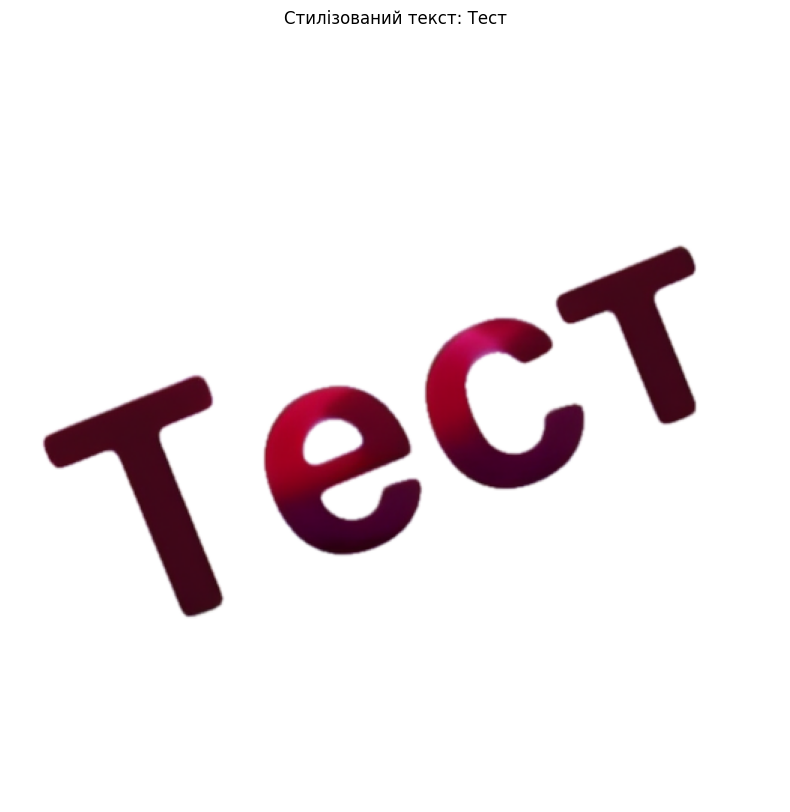

In [7]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import numpy as np

# 1. Оновлена функція рендеру, яка приймає бажаний текст як аргумент
def render_and_warp_cyrillic_text_dynamic(target_text: str, geometry_params: dict, canvas_size: tuple = (512, 512)) -> np.ndarray:
    base_image = Image.new("L", (1024, 1024), color=0)
    draw_context = ImageDraw.Draw(base_image)
    
    try:
        font = ImageFont.truetype("arialbd.ttf", 150)
    except IOError:
        font = ImageFont.load_default()
        
    # Рендер і обрізка українського слова
    bounding_box = draw_context.textbbox((0, 0), target_text, font=font)
    text_width = bounding_box[2] - bounding_box[0]
    text_height = bounding_box[3] - bounding_box[1]
    
    draw_context.text((512 - text_width//2, 512 - text_height//2), target_text, fill=255, font=font)
    rendered_array = np.array(base_image)
    rx, ry, rw, rh = cv2.boundingRect(rendered_array)
    cropped_cyrillic = rendered_array[ry:ry+rh, rx:rx+rw]
    
    h_ukr, w_ukr = cropped_cyrillic.shape
    
    # 1. ОТРИМУЄМО 4 КУТИ КОРЕЙСЬКОГО ТЕКСТУ
    kor_corners = geometry_params["corners"]
    
    # Визначаємо чи текст вертикальний чи горизонтальний (довжина верхньої грані vs лівої грані)
    top_edge_len = np.linalg.norm(kor_corners[0] - kor_corners[1])
    left_edge_len = np.linalg.norm(kor_corners[0] - kor_corners[3])
    
    ukr_corners = np.zeros((4, 2), dtype="float32")
    
    # 2. РОЗУМНЕ ПРИВ'ЯЗУВАННЯ КУТІВ
    if top_edge_len >= left_edge_len: 
        # Горизонтальний текст: просто мапимо кути 1 до 1
        ukr_corners[0] = [0, 0]             # Верх-Ліво
        ukr_corners[1] = [w_ukr, 0]         # Верх-Право
        ukr_corners[2] = [w_ukr, h_ukr]     # Низ-Право
        ukr_corners[3] = [0, h_ukr]         # Низ-Ліво
    else: 
        # Вертикальний текст: "кладемо" українське слово на бік (оберт 90 градусів)
        ukr_corners[0] = [0, h_ukr]         # Низ-Ліво стає Верхом-Ліво
        ukr_corners[1] = [0, 0]             # Верх-Ліво стає Верхом-Право
        ukr_corners[2] = [w_ukr, 0]         # Верх-Право стає Низом-Право
        ukr_corners[3] = [w_ukr, h_ukr]     # Низ-Право стає Низом-Ліво

    # 3. ЦЕНТРУВАННЯ ТА МАСШТАБУВАННЯ МАСКИ
    # Знаходимо реальні габарити деформованого чотирикутника
    min_x = np.min(kor_corners[:, 0])
    max_x = np.max(kor_corners[:, 0])
    min_y = np.min(kor_corners[:, 1])
    max_y = np.max(kor_corners[:, 1])
    
    w_kor = max_x - min_x
    h_kor = max_y - min_y
    
    # Якщо маска занадто велика для 512x512 — пропорційно зменшуємо її
    scale = 1.0
    if w_kor > canvas_size[0] - 40 or h_kor > canvas_size[1] - 40:
        scale = min((canvas_size[0] - 40) / max(w_kor, 1), (canvas_size[1] - 40) / max(h_kor, 1))
        
    centered_kor_corners = np.zeros_like(kor_corners)
    offset_x = (canvas_size[0] - w_kor * scale) / 2
    offset_y = (canvas_size[1] - h_kor * scale) / 2
    
    # Перераховуємо координати так, щоб деформація відбулася рівно по центру полотна
    for i in range(4):
        centered_kor_corners[i][0] = (kor_corners[i][0] - min_x) * scale + offset_x
        centered_kor_corners[i][1] = (kor_corners[i][1] - min_y) * scale + offset_y

    # 4. ПЕРСПЕКТИВНА ДЕФОРМАЦІЯ (МАГІЯ)
    # Вираховуємо матрицю, яка перетворить рівне слово на нахилену трапецію
    matrix = cv2.getPerspectiveTransform(ukr_corners, centered_kor_corners)
    
    # Застосовуємо деформацію до зображення
    warped_text = cv2.warpPerspective(cropped_cyrillic, matrix, canvas_size, flags=cv2.INTER_CUBIC)
    
    _, binary_warped_mask = cv2.threshold(warped_text, 127, 255, cv2.THRESH_BINARY)
    
    return binary_warped_mask

# ==========================================
# ГОЛОВНИЙ БЛОК ВИКОНАННЯ (MAIN)
# ==========================================

# 2. Налаштування вхідних даних
KOREAN_MASK_PATH = "../inpaint_mask.png"   # Шлях до чорно-білої маски корейського тексту
KOREAN_IMG_PATH = "../imgs/5.jpg"     # Шлях до кольорового оригіналу
KOREAN_STYLE_PATH = KOREAN_IMG_PATH                   # Референс стилю (зазвичай той самий кольоровий оригінал)
TARGET_UKR_TEXT = "Тест"                              # Ваш бажаний текст

OUTPUT_IMAGE_PATH = "stylized_ukr_result.png"

def run_typography_pipeline():
    print("1. Аналіз корейського оригіналу...")
    extractor = TypographyFeatureExtractor(KOREAN_MASK_PATH, KOREAN_IMG_PATH)
    
    geo_params = extractor.extract_geometric_ratio()
    edge_style = extractor.analyze_edge_morphology()
    tex_params = extractor.detect_texture_and_gradients()
    
    print(f"   - Геометрія: {geo_params}")
    print(f"   - Стиль країв: {edge_style}")
    print(f"   - Текстура: {tex_params}")

    print("\n2. Генерація та деформація українського тексту...")
    base_mask = render_and_warp_cyrillic_text_dynamic(TARGET_UKR_TEXT, geo_params)

    print("\n3. Адаптація морфології країв...")
    adapted_mask = apply_morphological_edge_adaptation(base_mask, edge_style)

    print("\n4. Перенесення стилю (Stable Diffusion XL)...")
    print("   [УВАГА: Цей процес вимагає GPU та може зайняти хвилину-дві]")
    stylized_rgb = generate_texture_zero_shot(adapted_mask, KOREAN_STYLE_PATH, tex_params)

    print("\n5. Фінальне композитування (додавання прозорості)...")
    final_rgba = final_image_compositing(stylized_rgb, adapted_mask)

    # Збереження результату
    cv2.imwrite(OUTPUT_IMAGE_PATH, final_rgba)
    print(f"\nГотово! Результат збережено як: {OUTPUT_IMAGE_PATH}")

    # Відображення результату прямо в Jupyter Notebook
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(final_rgba, cv2.COLOR_BGRA2RGBA))
    plt.axis('off')
    plt.title(f"Стилізований текст: {TARGET_UKR_TEXT}")
    plt.show()

# Запуск конвеєра
run_typography_pipeline()